In [34]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import sys

# import custom libraries
sys.path.append('../')
from neural_net import NeuralNet
import graphics

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
def unpickle(file):
    with open(file, 'rb') as fo:
        d = pickle.load(fo, encoding='bytes')
    return d

In [36]:
data_dir = "CIFAR_10"

batches =  [unpickle(os.path.join(data_dir, f'data_batch_{i}')) for i in range(1, 6)]

X_train = np.vstack([b[b'data'] for b in batches]) / 255.0
y_train = np.hstack([b[b'labels'] for b in batches])

test = unpickle(os.path.join(data_dir, 'test_batch'))
X_test  = test[b'data'] / 255.0
y_test  = np.array(test[b'labels'])


meta = unpickle(os.path.join(data_dir, 'batches.meta'))
class_names = [n.decode() for n in meta[b'label_names']]

C:\Users\EIpro\AppData\Local\Temp\ipykernel_440\3501123843.py:3: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = pickle.load(fo, encoding='bytes')


In [37]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Class names: {class_names}")

X_train shape: (50000, 3072)
y_train shape: (50000,)
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


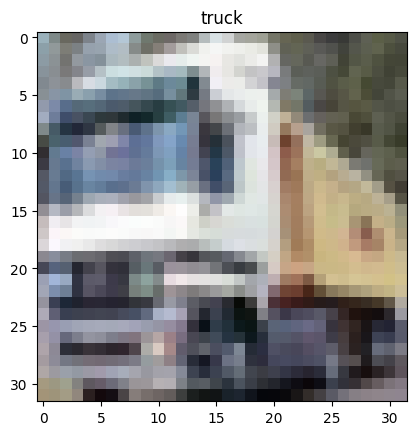

In [38]:
def show_image(X, label):
    red = np.reshape(X[:1024], (-1, 32))
    green = np.reshape(X[1024:2048], (-1, 32))
    blue = np.reshape(X[2048:], (-1, 32))

    rgb = np.dstack((red, green, blue))

    plt.title(label)
    plt.imshow(rgb)
        
show_image(X_train[1], class_names[y_train[1]])

In [ ]:
neural_net = NeuralNet((3*32**2, 1024, 512, 10), learning_rate=0.000001, random_state = 42)

neural_net.layers[0].activation_method="ReLu"
neural_net.layers[0].weights = neural_net.layers[0].initialize("He")

#neural_net.layers[1].activation_method="ReLu"
#neural_net.layers[1].weights = neural_net.layers[1].initialize("He")

#neural_net.layers[2].activation_method="ReLu"
#neural_net.layers[2].weights = neural_net.layers[2].initialize("He")

neural_net.layers[-1].activation_method="softmax"
epochs = 50
losses, y_pred = neural_net.train(X_train[0:1000],
                                  y_train[0:1000],
                                  epochs,
                                  batch_size = 10,
                                  validate=(X_train[0:100], y_train[0:100]),
                                  categorical=True,
                                  lr_scheduling=True)

EPOCH: 1    LOSS: 10.7106    LOSS CHANGE: 0    TEST ACCURACY: 0.06    TEST ACCURACY CHANGE 0.06
EPOCH: 2    LOSS: 10.672    LOSS CHANGE: -0.03859    TEST ACCURACY: 0.06    TEST ACCURACY CHANGE 0
EPOCH: 3    LOSS: 10.9123    LOSS CHANGE: 0.2403    TEST ACCURACY: 0.06    TEST ACCURACY CHANGE 0
EPOCH: 4    LOSS: 10.9077    LOSS CHANGE: -0.004595    TEST ACCURACY: 0.06    TEST ACCURACY CHANGE 0
EPOCH: 5    LOSS: 10.9009    LOSS CHANGE: -0.006842    TEST ACCURACY: 0.06    TEST ACCURACY CHANGE 0
EPOCH: 6    LOSS: 10.855    LOSS CHANGE: -0.0459    TEST ACCURACY: 0.06    TEST ACCURACY CHANGE 0
EPOCH: 7    LOSS: 11.1144    LOSS CHANGE: 0.2595    TEST ACCURACY: 0.06    TEST ACCURACY CHANGE 0
EPOCH: 8    LOSS: 11.073    LOSS CHANGE: -0.04139    TEST ACCURACY: 0.06    TEST ACCURACY CHANGE 0
EPOCH: 9    LOSS: 11.2755    LOSS CHANGE: 0.2024    TEST ACCURACY: 0.06    TEST ACCURACY CHANGE 0
EPOCH: 10    LOSS: 11.2714    LOSS CHANGE: -0.004075    TEST ACCURACY: 0.06    TEST ACCURACY CHANGE 0
EPOCH: 11 

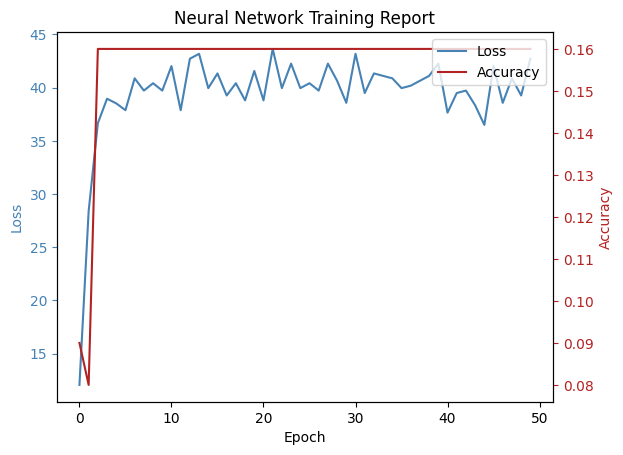

In [ ]:
graphics.plot_report(neural_net)